# Grouped BNN Posterior-Recovery Experiments

This notebook evaluates flow-based variational inference for grouped Bayesian neural-network selection against an MCMC reference posterior. The experiments isolate two selection targets:

- **hidden-unit selection**, where a complete hidden unit is treated as one selectable group;
- **original-variable selection**, where an input variable is selected through the corresponding column of the first-layer weight matrix.

All experiments use a shallow ReLU network, a plain ReLU relaxation, no linear shortcut, and the same decoder/prior for RaT and MCMC.


In [1]:
import sys
from pathlib import Path
import torch

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [21]:
%load_ext autoreload
%autoreload 2

import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

import Python.config as cfg
import Python.utils as ut
import Python.simfun as sim
import Python.model2 as md
import Python.metric as me
import Python.bnn_mcmc as mcmc
import Python.bnn_train as train

seed = 123
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# A--J checks from the grouped-model specification.
acceptance = md.run_grouped_acceptance_tests(device=device)
acceptance


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'hidden_units': 3,
 'scalar_slabs': 13,
 'unit_groups': 3,
 'group_activations': 3,
 'one_gate_per_unit': True,
 'unit_gate_applied_once': True,
 'plain_relu_gate': True,
 'relu_hidden_activation': True,
 'attention_input_output_metadata': True,
 'embedding_removed': True,
 'extra_output_projection_removed': True,
 'b2_removed': True,
 'linear_skip_default': False,
 'flow_inverse_error': 8.881784197001252e-16,
 'flow_logdet_error': 4.440892098500626e-16,
 'conditioner_independence_error': 0.0,
 'random_mask_dependency_coverage': True}

## Model, relaxation, and posterior approximation

### Shallow ReLU model

For scalar output, the fitted network is

$$
f(x)
=
\beta_0+
\sum_{j=1}^{H}
g_j\,W_{2j}\,
\operatorname{ReLU}\!\left(W_{1j}^{\top}x+b_{1j}\right).
$$

There is **no embedding layer, no extra output projection, and no linear skip connection** in these experiments.

### Unit-level selection

A hidden unit is treated as one group,

$$
G_j^{U}
=
\left\{
W_1[j,:],\; b_1[j],\; W_2[:,j]
\right\}.
$$

Its hard inclusion state is

$$
I_j = I(u_j>t).
$$

Because repeated occurrences of the same binary indicator satisfy

$$
I_j^m=I_j,
$$

the continuous relaxation is applied **once to the unit contribution**, rather than once to every parameter block:

$$
g_j
=
\operatorname{ReLU}(u_j-t).
$$

Thus one selectable unit corresponds to one activation latent, one threshold comparison, and one relaxed gate.

### Variable-level selection

For original variable \(k\),

$$
G_k^{F}=W_1[:,k],
$$

with one activation latent and one ReLU gate for each input variable. The unit- and variable-selection experiments therefore share the same selection principle: **one selectable object, one gate**.

### Attention-conditioned affine flow

The variational posterior starts from a diagonal Gaussian base and applies \(K=8\) attention-conditioned affine coupling transformations. Token metadata identify the latent coordinate, parameter type, group, unit, and parameter side. In particular, `input` and `output` remain available to the attention conditioner as structural metadata, but they **do not define separate selection gates**.

The affine-coupling masks are fixed at model construction and use balanced complementary partitions across coupling cycles.

### MCMC reference

MCMC uses the **same grouped decoder and prior** as the variational model. Setting `K_flow=0` removes only the variational transport; it does not change the target model.


## Evaluation criteria

The train/validation/test split is \(60\%/20\%/20\%\). Model selection uses validation signal recovery, while final posterior and prediction diagnostics are computed on the retained posterior draws.

The main quantities should be read as follows:

- **Signal \(R^2\)**: coefficient of determination against the noiseless teacher signal. Higher is better.
- **MSE**: prediction error against the noiseless teacher signal. Lower is better.
- **PIP RMSE vs MCMC**: root mean squared difference between RaT and MCMC posterior inclusion probabilities. Lower means closer agreement with MCMC; it is **not** the same as error relative to the simulation truth.
- **Conditional slab SKL**: symmetric KL divergence between RaT and MCMC slab-strength distributions for a truth-active target, conditional on that target being active. Lower is better.
- **Zero JS**: Jensen--Shannon divergence for the inactive/zero component. Lower is better.
- **True-active joint posterior density**: a two-dimensional density comparison for the two truth-active targets, conditional on both being active in the same posterior draw. If too few joint-active RaT draws are available, the plot is intentionally suppressed; this is itself evidence of selection failure.
- **ELBO**: the variational optimization objective. It is useful for optimization diagnostics but is not the main cross-case recovery metric.

In [22]:
# -----------------------------
# Shared run settings and helper
# -----------------------------

run_cfg = dict(
    mcmc_N=2500,
    mcmc_burnin=500,
    epochs=2500,
    R_train=100,
    R_eval=300,
    R_final=1000,
    eval_every=250,
)


def arch(p, H, linear_skip=False):
    return dict(
        input_dim=p,
        H=H,
        out_dim=1,
        gate_power=1.0,
        gate_tau=None,
        repu_power=None,
        linear_skip=linear_skip,
    )


def fit_case(label, data, selection_mode, architecture, case_seed=123):
    X, y, feature_true, unit_true, signal, info = data
    split_cfg = cfg.SplitConfig(
        train_frac=0.60,
        val_frac=0.20,
        test_frac=0.20,
        seed=case_seed,
    )
    indices = ut.make_split(X.shape[0], split_cfg)
    splits = ut.split_data(X, y, indices, mode="tensor")
    signal_splits = ut.split_data(X, signal, indices, mode="tensor")

    # MCMC uses exactly the same decoder/prior. K_flow=0 only removes the
    # variational transport; run_bnn_mcmc itself is decoder-agnostic.
    mcmc_model = md.GroupedBNNVI(
        X=splits["X_train"],
        y=splits["y_train"],
        selection_mode=selection_mode,
        family=info["family"],
        sigma2=info["sigma2"],
        init_sd=0.5,
        K_flow=0,
        flow_type="meanfield",
        **architecture,
    ).to(device)

    mcmc_ref = mcmc.run_bnn_mcmc(
        model=mcmc_model,
        N=run_cfg["mcmc_N"],
        S_max=100,
        burnin=run_cfg["mcmc_burnin"],
        thin=1,
        seed=case_seed,
        print_every=250,
    )
    mcmc_xi = torch.as_tensor(
        mcmc_ref["xi_draws"],
        device=device,
        dtype=X.dtype,
    )

    out = train.train_grouped_bnn(
        X_train=splits["X_train"],
        y_train=splits["y_train"],
        X_eval=splits["X_val"],
        signal_eval=signal_splits["y_val"],
        X_final=splits["X_test"],
        signal_final=signal_splits["y_test"],
        mcmc_decoder=mcmc_model.decoder,
        mcmc_xi=mcmc_xi,
        truth=info,
        selection_mode=selection_mode,
        family=info["family"],
        sigma2=info["sigma2"],
        init_sd=0.5,
        K_flow=8,
        flow_type="attention_affine",
        flow_hidden_units=64,
        flow_hidden_layers=2,
        scale_clip=1.5,
        flow_token_dim=32,
        flow_num_heads=4,
        flow_mask_seed=case_seed,
        epochs=run_cfg["epochs"],
        lr=3e-4,
        R_train=run_cfg["R_train"],
        R_eval=run_cfg["R_eval"],
        R_final=run_cfg["R_final"],
        eval_every=run_cfg["eval_every"],
        seed=case_seed,
        **architecture,
    )

    final = out["final"]
    summary = final["summary"]

    print("\n" + "=" * 76)
    print(label)
    print("=" * 76)
    print(
        f"selection mode : {selection_mode}\n"
        f"latent dim     : {mcmc_ref['latent_dim']}\n"
        f"MCMC kept      : {mcmc_ref['n_kept']}\n"
        f"best epoch     : {summary['best_epoch']}\n"
        f"linear skip    : {architecture.get('linear_skip', False)}"
    )

    summary_cols = [
        "best_val_signal_r2",
        "pip_rmse_mcmc",
        "true_active_skl",
        "n_valid_true_active_skl",
        "n_truth_active",
        "zero_js",
        "rat_signal_r2",
        "mcmc_signal_r2",
        "rat_mse",
        "mcmc_mse",
        "elbo",
    ]
    summary_cols = [name for name in summary_cols if name in summary]

    print("\n--- Final summary ---")
    display(pd.DataFrame([summary])[summary_cols].round(4))

    print("\n--- Recovery by target ---")
    display(final["recovery_by_target"].round(4))

    print("\n--- Group posterior ---")
    display(final["group_metrics"].round(4))

    if not final["unit_metrics"].empty:
        print("\n--- Unit posterior ---")
        display(final["unit_metrics"].round(4))

    if "teacher_units" in info:
        print("\n--- Teacher units ---")
        display(pd.DataFrame(info["teacher_units"]).round(4))


    print("\n--- True-active joint posterior density ---")

    fig, ax = me.plot_true_active_joint_density(
        rat_decoder=out["model"].decoder,
        rat_xi=final["xi"],
        mcmc_decoder=mcmc_model.decoder,
        mcmc_xi=mcmc_xi,
        truth=info,
        min_draws=50,
    )

    if fig is not None:
        ax.set_title(
            f"{label}: true-active joint posterior"
        )
        plt.show()

    # Plot immediately for one-dimensional cases on a dense grid.
    if X.shape[1] == 1:
        x_low, x_high = info["x_range"]
        x_grid = torch.linspace(
            x_low,
            x_high,
            400,
            device=device,
            dtype=X.dtype,
        )[:, None]
        signal_grid = sim.evaluate_grouped_teacher(x_grid, info)
        mcmc_grid = me.predict_draws(
            mcmc_model.decoder, x_grid, mcmc_xi
        )
        rat_grid = me.predict_draws(
            out["model"].decoder, x_grid, final["xi"]
        )
        fig, ax = me.plot_function_1d(
            x=x_grid[:, 0].detach().cpu(),
            signal=signal_grid.detach().cpu(),
            mcmc_pred_draws=mcmc_grid,
            rat_pred_draws=rat_grid,
            method_label="RaT",
        )
        ax.set_title(label)
        plt.show()

    return {
        "label": label,
        "data": data,
        "splits": splits,
        "signal_splits": signal_splits,
        "mcmc_model": mcmc_model,
        "mcmc_xi": mcmc_xi,
        "mcmc_ref": mcmc_ref,
        "out": out,
    }


## Experiment A — \(p=1\), hidden-unit selection

**Data.** \(n=160\), one input variable, Gaussian noise with \(\sigma^2=1\), two truth-active ReLU units, and \(H=5\) candidate units in the fitted model.

**Purpose.** This is the low-dimensional unit-selection sanity check. Because the input direction is one-dimensional, the experiment mainly tests whether the single-gate unit parameterization can recover the correct number of nonlinear components and their posterior strengths.

**Primary diagnostics.** Signal \(R^2\), ranked-unit PIPs, conditional slab SKL for the first two truth-active ranks, joint active density, and the one-dimensional function-recovery plot.

mcmc_iter=00001 loglik=-532.642
mcmc_iter=00250 loglik=-138.618
mcmc_iter=00500 loglik=-141.988
mcmc_iter=00750 loglik=-137.925
mcmc_iter=01000 loglik=-138.873
mcmc_iter=01250 loglik=-139.106
mcmc_iter=01500 loglik=-138.283
mcmc_iter=01750 loglik=-138.357
mcmc_iter=02000 loglik=-139.522
mcmc_iter=02250 loglik=-142.042
mcmc_iter=02500 loglik=-138.667
epoch=0001 valR2=-6.9889 pipRMSE=0.5354 trueSKL=5.1056 zeroJS=0.2545
epoch=0250 valR2=0.9600 pipRMSE=0.3174 trueSKL=2.5036 zeroJS=0.1234
epoch=0500 valR2=0.9366 pipRMSE=0.6572 trueSKL=0.6563 zeroJS=0.4204
epoch=0750 valR2=0.9639 pipRMSE=0.6488 trueSKL=0.4753 zeroJS=0.4310
epoch=1000 valR2=0.9674 pipRMSE=0.5917 trueSKL=0.3256 zeroJS=0.4122
epoch=1250 valR2=0.9463 pipRMSE=0.5515 trueSKL=0.2975 zeroJS=0.3917
epoch=1500 valR2=0.9615 pipRMSE=0.5125 trueSKL=0.1946 zeroJS=0.3539
epoch=1750 valR2=0.9269 pipRMSE=0.5280 trueSKL=0.2262 zeroJS=0.3901
epoch=2000 valR2=0.9800 pipRMSE=0.5072 trueSKL=0.2721 zeroJS=0.3613
epoch=2250 valR2=0.9538 pipRMSE=0.5

,best_val_signal_r2,pip_rmse_mcmc,true_active_skl,n_valid_true_active_skl,n_truth_active,zero_js,rat_signal_r2,mcmc_signal_r2,rat_mse,mcmc_mse,elbo
0,0.98,0.5066,0.2709,2,2,0.3539,0.9717,0.9457,0.0854,0.1636,-158.9936



--- Recovery by target ---


,target_type,target,label,truth_active,rat_pip,mcmc_pip,pip_error,conditional_slab_skl,zero_mass_js,n_rat_active_draws,n_mcmc_active_draws
0,unit_rank,0,unit_rank_1,True,1.000,1.000,0.000,0.1951,NaN,1000,2000
1,unit_rank,1,unit_rank_2,True,1.000,1.000,0.000,0.3467,NaN,1000,2000
2,unit_rank,2,unit_rank_3,False,0.646,0.999,-0.353,NaN,0.1387,646,1998
3,unit_rank,3,unit_rank_4,False,0.229,0.982,-0.753,NaN,0.3566,229,1964
4,unit_rank,4,unit_rank_5,False,0.040,0.809,-0.769,NaN,0.3539,40,1618



--- Group posterior ---


...


--- Unit posterior ---


,method,epoch,block,unit,group_id,posterior_rank,unit_pip,gate_mean,margin_mean,margin_sd,input_slab_norm_mean,output_slab_norm_mean,slab_strength_mean,effective_strength_mean
0,RaT,2000,0,2,2,1,1.0000,1.3408,1.3408,0.4717,1.5672,1.1041,1.6961,2.0162
1,RaT,2000,0,3,3,2,1.0000,1.2879,1.2879,0.4369,1.4588,1.0594,1.4756,1.7104
2,RaT,2000,0,4,4,3,0.3360,0.1720,-0.3472,0.7968,1.1935,0.6971,0.8392,0.0718
3,RaT,2000,0,0,0,4,0.3020,0.1427,-0.3879,0.7384,1.1404,0.6091,0.6997,0.0499
4,RaT,2000,0,1,1,5,0.2770,0.1436,-0.4172,0.7544,1.1132,0.6626,0.7538,0.0649
5,MCMC,None,0,3,3,1,0.9740,1.8717,1.8587,0.8593,1.3441,0.8285,0.9272,1.6662
6,MCMC,None,0,4,4,2,0.9580,1.8609,1.8373,1.0318,1.0998,0.7603,0.7983,1.3344
7,MCMC,None,0,2,2,3,0.9555,1.6446,1.6216,1.0346,1.4757,0.7110,0.9758,1.3610
8,MCMC,None,0,0,0,4,0.9520,1.7130,1.6838,0.9674,1.1355,0.8242,0.9093,1.4218
9,MCMC,None,0,1,1,5,0.9505,1.7203,1.6956,0.9710,1.1413,0.7469,0.8105,1.3204



--- Teacher units ---


,teacher_unit,feature,slope,breakpoint,bias,amplitude
0,0,0,0.8992,-0.4708,-0.4233,1.9300
1,1,0,-0.8792,0.4286,-0.3768,2.8267



--- True-active joint posterior density ---
joint-active draws: RaT=1000, MCMC=2000
joint-active probability: RaT=1.0000, MCMC=1.0000
conditional joint SKL: 0.5128


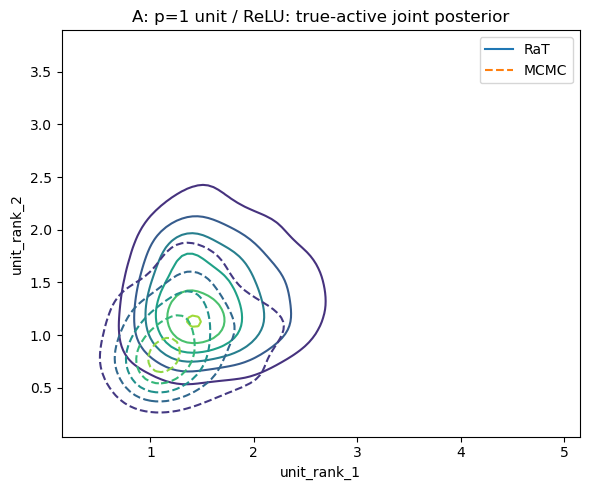

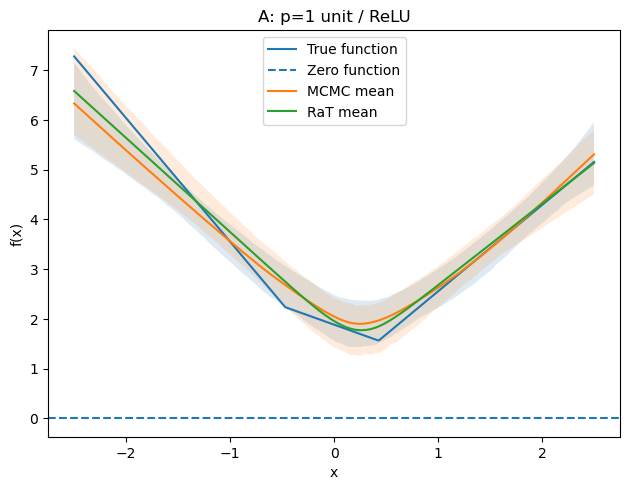

In [25]:
# -----------------------------------------
# A. p=1: hidden-unit selection with ReLU
# -----------------------------------------

data_A = sim.simfun_grouped_bnn(
    n=160,
    p=1,
    active_features=(0,),
    n_true_units=2,
    fit_units=5,
    repu_power=None,
    sigma2=1.0,
    seed=seed,
    device=device,
)

case_A = fit_case(
    label="A: p=1 unit / ReLU",
    data=data_A,
    selection_mode="unit_group",
    architecture=arch(p=1, H=5),
    case_seed=seed,
)


### Experiment A — result interpretation

The single-gate unit model recovers the nonlinear signal well. The selected checkpoint reaches validation signal \(R^2=0.9800\), with test signal \(R^2=0.9717\) for RaT compared with \(0.9457\) for MCMC. The two truth-active ranked units both have RaT PIP \(=1.000\), matching MCMC on the active ranks.

Posterior recovery for the active components is also reasonable: the two conditional slab SKLs are \(0.1951\) and \(0.3467\), and the conditional two-dimensional joint SKL is \(0.5128\). All RaT and MCMC draws used for the joint comparison contain both truth-active ranks, so the joint density is well defined.

The comparatively large PIP RMSE against MCMC (\(0.5066\)) should not be read as failure of the two active units. The disagreement is concentrated in the inactive ranks: MCMC assigns very high inclusion probabilities to additional ranked units, whereas RaT is substantially sparser. RaT is not perfectly sparse either—the third ranked unit still has PIP \(0.646\)—but the main active structure and the regression function are recovered successfully.

## Shared multivariable teacher for Experiments B and C

Experiments B and C use the same simulated data so that unit selection and variable selection are compared under an identical nonlinear signal.

The data have \(n=240\), \(p=6\), Gaussian noise with \(\sigma^2=1\), and exactly two active original variables, \(x_0\) and \(x_3\). The teacher contains two ReLU units: one aligned with \(x_0\) and one aligned with \(x_3\). The fitted network uses \(H=6\) candidate hidden units.

The only substantive difference between B and C is therefore the **selection target**.

In [23]:
# -----------------------------------------------------
# One multivariable teacher used by experiments B and C
# -----------------------------------------------------

data_multi = sim.simfun_grouped_bnn(
    n=240,
    p=6,
    active_features=(0, 3),
    n_true_units=2,
    fit_units=6,
    repu_power=None,
    sigma2=1.0,
    seed=seed + 1,
    device=device,
)

pd.DataFrame(data_multi[-1]["teacher_units"])


,teacher_unit,feature,slope,breakpoint,bias,amplitude
0,0,0,1.236111,0.045640,0.056417,1.081308
1,1,3,-1.094998,0.045737,-0.050082,1.189073


## Experiment B — \(p=6\), hidden-unit selection

**Data.** The shared \(p=6\) teacher is fitted with six candidate units, while the simulation truth contains two active units.

**Selection target.** Each complete hidden unit

$$
\{W_1[j,:],\,b_1[j],\,W_2[:,j]\}
$$

is one group with one activation latent and one ReLU gate.

**Primary diagnostics.** Ranked-unit PIPs, gate/margin summaries, slab norms, signal \(R^2\), and availability of the two-dimensional truth-active joint density. The latter requires both truth-active ranked units to be simultaneously active in enough posterior draws.

In [24]:
# -----------------------------------------
# B. p=6: hidden-unit selection with ReLU
# -----------------------------------------

case_B = fit_case(
    label="B: p=6 unit / ReLU",
    data=data_multi,
    selection_mode="unit_group",
    architecture=arch(p=6, H=6),
    case_seed=seed + 1,
)


mcmc_iter=00001 loglik=-342.781
mcmc_iter=00250 loglik=-202.676
mcmc_iter=00500 loglik=-201.664
mcmc_iter=00750 loglik=-204.185
mcmc_iter=01000 loglik=-203.649
mcmc_iter=01250 loglik=-204.908
mcmc_iter=01500 loglik=-198.058
mcmc_iter=01750 loglik=-200.031
mcmc_iter=02000 loglik=-203.122
mcmc_iter=02250 loglik=-202.847
mcmc_iter=02500 loglik=-203.153
epoch=0001 valR2=-1.0679 pipRMSE=0.2091 trueSKL=5.0927 zeroJS=0.0448
epoch=0250 valR2=-0.0084 pipRMSE=0.6121 trueSKL=nan zeroJS=0.0251
epoch=0500 valR2=-0.0085 pipRMSE=0.6085 trueSKL=nan zeroJS=0.0251
epoch=0750 valR2=-0.0099 pipRMSE=0.6049 trueSKL=nan zeroJS=0.0251
epoch=1000 valR2=-0.0078 pipRMSE=0.6022 trueSKL=nan zeroJS=0.0251
epoch=1250 valR2=-0.0133 pipRMSE=0.5933 trueSKL=nan zeroJS=0.0251
epoch=1500 valR2=-0.0131 pipRMSE=0.6040 trueSKL=nan zeroJS=0.0251
epoch=1750 valR2=-0.0081 pipRMSE=0.5978 trueSKL=nan zeroJS=0.0251
epoch=2000 valR2=-0.0087 pipRMSE=0.6040 trueSKL=nan zeroJS=0.0251
epoch=2250 valR2=-0.0066 pipRMSE=0.6045 trueSKL=nan

,best_val_signal_r2,pip_rmse_mcmc,true_active_skl,n_valid_true_active_skl,n_truth_active,zero_js,rat_signal_r2,mcmc_signal_r2,rat_mse,mcmc_mse,elbo
0,-0.0066,0.603,NaN,0,2,0.0251,-0.0039,0.9486,2.4886,0.1274,-365.109



--- Recovery by target ---


,target_type,target,label,truth_active,rat_pip,mcmc_pip,pip_error,conditional_slab_skl,zero_mass_js,n_rat_active_draws,n_mcmc_active_draws
0,unit_rank,0,unit_rank_1,True,0.034,1.0000,-0.9660,NaN,NaN,34,2000
1,unit_rank,1,unit_rank_2,True,0.000,1.0000,-1.0000,NaN,NaN,0,2000
2,unit_rank,2,unit_rank_3,False,0.000,0.4830,-0.4830,NaN,0.2065,0,966
3,unit_rank,3,unit_rank_4,False,0.000,0.1205,-0.1205,NaN,0.0437,0,241
4,unit_rank,4,unit_rank_5,False,0.000,0.0185,-0.0185,NaN,0.0065,0,37
5,unit_rank,5,unit_rank_6,False,0.000,0.0000,0.0000,NaN,0.0000,0,0



--- Group posterior ---


...


--- Unit posterior ---


,method,epoch,block,unit,group_id,posterior_rank,unit_pip,gate_mean,margin_mean,margin_sd,input_slab_norm_mean,output_slab_norm_mean,slab_strength_mean,effective_strength_mean
0,RaT,2250,0,5,5,1,0.0120,0.0008,-1.6065,0.8941,2.4702,0.7652,1.8737,0.0014
1,RaT,2250,0,3,3,2,0.0070,0.0007,-1.6574,0.8949,2.4290,0.7647,1.8535,0.0014
2,RaT,2250,0,2,2,3,0.0050,0.0004,-1.6417,0.8623,2.4914,0.7362,1.8363,0.0004
3,RaT,2250,0,4,4,4,0.0050,0.0006,-1.5778,0.8370,2.4310,0.7584,1.8420,0.0012
4,RaT,2250,0,1,1,5,0.0040,0.0002,-1.6568,0.9027,2.4350,0.7815,1.8873,0.0007
5,RaT,2250,0,0,0,6,0.0010,0.0002,-1.6867,0.8680,2.4606,0.7800,1.9209,0.0003
6,MCMC,None,0,1,1,1,1.0000,0.9896,0.9896,0.4656,2.5561,0.6821,1.6693,1.3463
7,MCMC,None,0,4,4,2,0.8470,0.5370,0.3715,0.7768,2.7071,1.1877,3.3645,1.2534
8,MCMC,None,0,3,3,3,0.3105,0.1535,-0.5157,0.9057,2.5063,0.8239,2.0593,0.3066
9,MCMC,None,0,2,2,4,0.1840,0.0614,-0.7591,0.8325,2.5600,0.7036,1.8099,0.0344



--- Teacher units ---


,teacher_unit,feature,slope,breakpoint,bias,amplitude
0,0,0,1.2361,0.0456,0.0564,1.0813
1,1,3,-1.0950,0.0457,-0.0501,1.1891



--- True-active joint posterior density ---
joint-active draws: RaT=0, MCMC=2000
joint-active probability: RaT=0.0000, MCMC=1.0000
Joint density not plotted: insufficient joint-active posterior draws.


### Experiment B — result interpretation

Experiment B fails at the **unit-selection stage**, not merely at fine posterior calibration. RaT gives test signal \(R^2=-0.0039\), whereas the MCMC reference gives \(0.9486\). The first two truth-active ranked units have RaT PIPs \(0.034\) and \(0.000\), compared with MCMC PIPs \(1.000\) and \(1.000\). Consequently, no truth-active conditional slab SKL can be computed.

The missing joint-density figure is expected rather than a plotting error. RaT has **zero** posterior draws in which both truth-active ranked units are simultaneously active, while MCMC has 2000 such draws. There is therefore no meaningful RaT two-dimensional conditional density to estimate.

#### Attribution

The current single-gate formulation rules out the previous explanation based on multiplying separate input- and output-side gates: each unit now has only one gate, and that gate is applied once. The remaining failure is a much cleaner **gate/margin collapse**.

Across all six RaT unit groups, PIPs are only \(0.001\)–\(0.012\), gate means are approximately \(2\times10^{-4}\) to \(8\times10^{-4}\), and mean margins remain deeply negative at about \(-1.58\) to \(-1.69\). By contrast, the slab norms remain large, around \(2.61\)–\(2.66\). The variational posterior is therefore not eliminating units by shrinking the slab parameters themselves; it is shutting off their contribution through the ReLU selection gate.

With

$$
g_j=\operatorname{ReLU}(u_j-t),
$$

a negative margin gives both \(g_j=0\) and zero local derivative through the gate. Once a candidate unit enters this inactive basin, likelihood gradients to the unit-specific network parameters are also strongly suppressed because the whole unit contribution is multiplied by \(g_j\). In the \(p=6\) unit-selection problem, each candidate unit must additionally learn a useful direction in a six-dimensional input space before opening that unit becomes beneficial. This creates a plausible optimization deadlock:

$$
g_j\approx0
\;\Rightarrow\;
\text{weak learning of the unit direction}
\;\Rightarrow\;
\text{little likelihood gain from opening the unit}
\;\Rightarrow\;
g_j\text{ remains inactive}.
$$

The contrast with Experiment C is important: the same ReLU relaxation and attention-affine posterior can recover the active original variables, so the evidence points specifically to the geometry and optimization of **high-dimensional unit groups**, rather than to a general failure of the flow or of the ReLU relaxation.


## Experiment C — \(p=6\), original-variable selection

**Data.** This experiment reuses exactly the same \(n=240\), \(p=6\) observations and two-unit teacher as Experiment B. The truth-active variables are \(x_0\) and \(x_3\).

**Selection target.** Variable \(k\) is selected through the first-layer column \(W_1[:,k]\), with one gate per original variable.

**Primary diagnostics.** Feature PIPs, active-feature conditional slab SKL, zero-mass JS for inactive features, signal \(R^2\), and the joint posterior density of the two truth-active feature strengths.

mcmc_iter=00001 loglik=-341.751
mcmc_iter=00250 loglik=-207.135
mcmc_iter=00500 loglik=-197.753
mcmc_iter=00750 loglik=-199.794
mcmc_iter=01000 loglik=-201.331
mcmc_iter=01250 loglik=-204.595
mcmc_iter=01500 loglik=-204.206
mcmc_iter=01750 loglik=-201.052
mcmc_iter=02000 loglik=-206.994
mcmc_iter=02250 loglik=-205.591
mcmc_iter=02500 loglik=-209.236
epoch=0001 valR2=-0.9149 pipRMSE=0.4068 trueSKL=6.8085 zeroJS=0.0594
epoch=0250 valR2=0.9906 pipRMSE=0.0717 trueSKL=1.1514 zeroJS=0.0085
epoch=0500 valR2=0.9895 pipRMSE=0.0975 trueSKL=0.5758 zeroJS=0.0241
epoch=0750 valR2=0.9825 pipRMSE=0.0980 trueSKL=0.4961 zeroJS=0.0210
epoch=1000 valR2=0.9854 pipRMSE=0.1133 trueSKL=0.2361 zeroJS=0.0408
epoch=1250 valR2=0.9911 pipRMSE=0.0944 trueSKL=0.1777 zeroJS=0.0192
epoch=1500 valR2=0.9850 pipRMSE=0.1061 trueSKL=0.2332 zeroJS=0.0305
epoch=1750 valR2=0.9875 pipRMSE=0.1091 trueSKL=0.1986 zeroJS=0.0358
epoch=2000 valR2=0.9837 pipRMSE=0.1046 trueSKL=0.2223 zeroJS=0.0277
epoch=2250 valR2=0.9874 pipRMSE=0.1

,best_val_signal_r2,pip_rmse_mcmc,true_active_skl,n_valid_true_active_skl,n_truth_active,zero_js,rat_signal_r2,mcmc_signal_r2,rat_mse,mcmc_mse,elbo
0,0.9911,0.1001,0.2087,2,2,0.0249,0.9868,0.984,0.0328,0.0396,-241.8621



--- Recovery by target ---


,target_type,target,label,truth_active,rat_pip,mcmc_pip,pip_error,conditional_slab_skl,zero_mass_js,n_rat_active_draws,n_mcmc_active_draws
0,feature,0,feature_0,True,1.000,1.0000,0.0000,0.2301,NaN,1000,2000
1,feature,1,feature_1,False,0.018,0.0925,-0.0745,NaN,0.0145,18,185
2,feature,2,feature_2,False,0.027,0.0860,-0.0590,NaN,0.0086,27,172
3,feature,3,feature_3,True,1.000,1.0000,0.0000,0.1873,NaN,1000,2000
4,feature,4,feature_4,False,0.032,0.1920,-0.1600,NaN,0.0353,32,384
5,feature,5,feature_5,False,0.005,0.1645,-0.1595,NaN,0.0510,5,329



--- Group posterior ---


,method,epoch,group_id,selection_type,block,feature,side,pip,gate_mean,margin_mean,margin_sd,slab_norm_mean,slab_norm_median
0,RaT,1250,0,feature,input,0,input,1.0000,0.8281,0.8281,0.1601,2.3193,2.3127
1,RaT,1250,1,feature,input,1,input,0.0180,0.0036,-0.9692,0.4718,2.4643,2.4111
2,RaT,1250,2,feature,input,2,input,0.0270,0.0038,-0.9778,0.5122,2.4203,2.3569
3,RaT,1250,3,feature,input,3,input,1.0000,0.7821,0.7821,0.1929,2.3130,2.2993
4,RaT,1250,4,feature,input,4,input,0.0320,0.0055,-0.8954,0.4725,2.4953,2.4567
5,RaT,1250,5,feature,input,5,input,0.0050,0.0003,-1.1032,0.4236,2.3479,2.2878
6,MCMC,None,0,feature,input,0,input,1.0000,1.2772,1.2772,0.6258,2.2029,2.1638
7,MCMC,None,1,feature,input,1,input,0.0925,0.0149,-0.8422,0.7435,2.3550,2.3252
8,MCMC,None,2,feature,input,2,input,0.0860,0.0133,-0.8790,0.7240,2.3293,2.3037
9,MCMC,None,3,feature,input,3,input,1.0000,1.1122,1.1122,0.5453,2.4916,2.4733



--- Teacher units ---


,teacher_unit,feature,slope,breakpoint,bias,amplitude
0,0,0,1.2361,0.0456,0.0564,1.0813
1,1,3,-1.0950,0.0457,-0.0501,1.1891



--- True-active joint posterior density ---
joint-active draws: RaT=1000, MCMC=2000
joint-active probability: RaT=1.0000, MCMC=1.0000


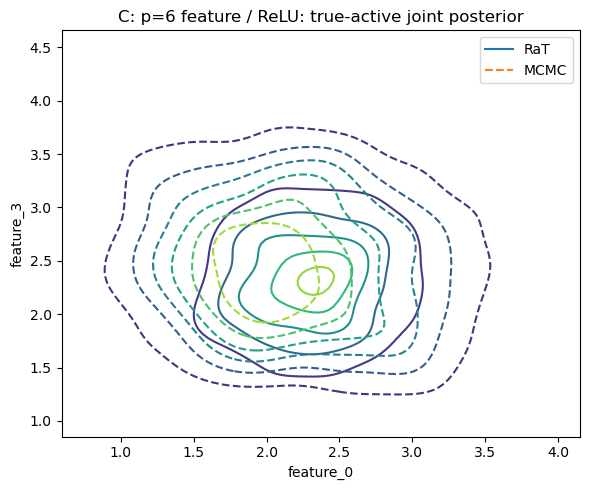

In [20]:
# --------------------------------------------
# C. p=6: original-variable selection via W1[:, k]
# --------------------------------------------

case_C = fit_case(
    label="C: p=6 feature / ReLU",
    data=data_multi,
    selection_mode="feature_group",
    architecture=arch(p=6, H=6),
    case_seed=seed + 1,
)


### Experiment C — result interpretation

Variable selection is recovered cleanly. The selected RaT checkpoint achieves validation signal \(R^2=0.9911\) and test signal \(R^2=0.9868\), essentially matching the MCMC test value \(0.9840\).

Both truth-active variables, \(x_0\) and \(x_3\), have RaT and MCMC PIP \(=1.000\). RaT assigns only \(0.005\)–\(0.032\) PIP to the four inactive variables. The active conditional slab SKLs are \(0.2301\) and \(0.1873\), with an average truth-active SKL of \(0.2087\). The inactive zero-mass discrepancy is also small, with zero JS \(=0.0249\).

The two-dimensional active posterior comparison is fully supported: all 1000 RaT draws and all 2000 MCMC draws contain both active features. The remaining PIP RMSE against MCMC (\(0.1001\)) is driven mainly by MCMC assigning non-negligible inclusion mass to inactive variables (\(0.086\)–\(0.192\)), whereas RaT is closer to the simulated sparse truth.

Taken together with Experiment B, this result shows that the current flow and plain ReLU gate can perform grouped selection successfully when the selectable object is an original variable. The unresolved difficulty is specific to hidden-unit selection in the multivariable setting.